### **Introduction**
This data analysis utilizes a dataset containing life expectancy and GDP data for five countries over multiple years. By examining both temporal and cross-country variations, the study seeks to uncover patterns that illustrate how improvements in economic growth may correspond to changes in population health outcomes.

#### **Project Scope**

- Investigates the relationship between life expectancy and economic performance (GDP) across five countries over multiple years.  
- Analyzes data patterns to understand how economic growth influences population health outcomes.  
- Summarizes and visualizes key statistics using tables, line plots, bar charts, and box plots to highlight variations and trends across time and countries.  
- Explores relationships between GDP and life expectancy through scatter plots, trend analysis, and correlation measures.  
- Applies statistical methods to evaluate the significance and strength of observed relationships between economic and health indicators.  
- Builds predictive models (e.g., regression) to estimate life expectancy based on GDP and time, assessing accuracy and reliability.  
- Combines data visualization, statistical analysis, and predictive modeling to deliver insights on the socioeconomic factors shaping global health and longevity.  


#### Data Overview
The dataset consists of 96 observations and four key attributes representing annual life expectancy and GDP data for six countries. It combines both cross-sectional and time-series characteristics, enabling comparative and trend-based analyses. The dataset comprises one categorical variable and three numeric variables:

- Categorical variable: Country
- Numeric variable: Year, Life expectancy at birth (years), GDP

---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import plotly.express as px
from pathlib import Path
import seaborn as sns
import scipy.stats as stats

life_data = pd.read_csv('all_data.csv')
life_data.info()
life_data.head()

Loading the CSV dataset and checking the data types containing life expectancy, years and GDP.

Data cleaning:
- Rename 'Life expectancy at birth (years)' to 'Life_expectancy_years'
- Update the country name from 'United States of America' to 'USA'.
- Convert GDP by dividing the column value by 1e9
- A new column 'GDP_in_billion' is created to handle large values of GDP

---

In [49]:
life_data.rename(columns={'Life expectancy at birth (years)': 'Life_expectancy_years'}, inplace=True)
life_data['Country'] = life_data['Country'].replace({'United States of America': 'USA'})
life_data['GDP_in_trillion'] = life_data['GDP'] / 1e12
# life_data.drop(columns=['GDP'], inplace=True)


#### Summary statistics
This stage focuses on identifying central tendencies, dispersion, and overall trends to build an initial understanding of the data before deeper exploration and modeling.
These statistics provide insight into the range and variability of life expectancy and GDP across all observations. 
- The mean and standard deviation help establish the central tendency and spread of each variable, 
- Minimum and Maximum values indicate the observed extremes across the dataset.
- Average of Life expectancy and GDP across the five selected countries

---

General Summary statistics (GDP Vs Life expectancy):

In [ ]:
life_data.describe()[['Life_expectancy_years', 'GDP_in_trillion']]

Summary statistics per Country:
1. variance
2. standard deviation
3. mean absolute deviation
4. mean
5. mode
6. median

In [51]:
summary_stats = life_data.groupby('Country')[['Life_expectancy_years', 'GDP_in_trillion']].agg(['var', 'std', 'mean', 'median']).reset_index()

summary_stats

Country Life_expectancy_years                            GDP_in_trillion  \
                              var       std      mean median             var   
0     Chile              1.121292  1.058911  78.94375  79.00        0.005910   
1     China              1.737167  1.318016  74.26250  74.45       12.257672   
2   Germany              0.950625  0.975000  79.65625  79.85        0.445538   
3    Mexico              0.385625  0.620987  75.71875  75.65        0.043920   
4       USA              0.693167  0.832566  78.06250  78.15        5.918000   
5  Zimbabwe             35.287292  5.940311  50.09375  47.40        0.000018   

                                   
        std       mean     median  
0  0.076879   0.169789   0.172997  
1  3.501096   4.957714   4.075195  
2  0.667486   3.094776   3.396350  
3  0.209572   0.976651   1.004375  
4  2.432694  14.075000  14.450000  
5  0.004298   0.009063   0.006734

Calculating frequency per Country:

In [52]:
life_data['Country'].value_counts()

Country
Chile       16
China       16
Germany     16
Mexico      16
USA         16
Zimbabwe    16
Name: count, dtype: int64

##### Comparison of GDP and Life Expectancy Across Countries

Using the `groupby` operation, we compute the average GDP and life expectancy for each country, providing an overview of their relative economic performance and health outcomes.

- **Germany** records the highest average life expectancy, while **Zimbabwe** has the lowest over the observed period.
- In terms of economic performance, the **United States** has by far the highest average GDP (approximately 14.8 trillion dollars), whereas **Zimbabwe** has the lowest (around 0.01 trillion dollars).

These summary statistics help illustrate clear disparities in both economic output and population health across the countries in the dataset.


In [53]:
life_data.groupby('Country')[['Life_expectancy_years', 'GDP_in_trillion']].mean().round(2)

,Life_expectancy_years,GDP_in_trillion
Country,,
Chile,78.94,0.17
China,74.26,4.96
Germany,79.66,3.09
Mexico,75.72,0.98
USA,78.06,14.08
Zimbabwe,50.09,0.01


Mininum and Maximum of Life expectancy and GDP respectively per country between 2000 and 2015

In [ ]:
print("==== Life Expectancy per country ====")
for country in life_data['Country'].unique():
    country_data = life_data[life_data['Country'] == country]
    print(f"{country}: ", "min= "+ str(int(country_data['Life_expectancy_years'].min())), ", max= "+ str(int(country_data['Life_expectancy_years'].max())))

print("\n==== GDP per country ====")
for country in life_data['Country'].unique():
    country_data = life_data[life_data['Country'] == country]
    print(f"{country}: ", "min= "+ str(float(round(country_data['GDP_in_trillion'].min(), 4))), ", max= "+ str(float(round(country_data['GDP_in_trillion'].max(), 4))))      

GDP descriptive statistics:

In [ ]:
def mad(x):
    # mean absolute deviation from the mean
    return np.mean(np.abs(x - x.mean()))

def mode(x):
    m = x.mode()
    if not m.empty:
        return m.iloc[0]
    else:
        return np.nan
    
def data_range(x):
    return x.max() - x.min()

stats_df = life_data.groupby("Country").agg({
    'GDP_in_trillion': ['mean',mode, data_range, 'median', mad, 'var', 'std']
}).reset_index()

print(stats_df)

Life expectancy descriptive statistics:

In [ ]:
stats_df = life_data.groupby("Country").agg({
    'Life_expectancy_years': ['mean',mode, data_range, 'median', mad, 'var', 'std']
}).reset_index()

print(stats_df)

### Interpretation of Life Expectancy and GDP Distributions

The visualization in **Fig. 1** presents the distribution of life expectancy across countries, emphasizing both the median values and the degree of variability. In **Fig. 2**, a logarithmic scale is applied to the GDP boxplot to account for large differences in economic size across countries. This transformation provides a more meaningful comparison and supports the investigation of whether higher national income levels are associated with greater or more stable life expectancy outcomes.

#### Key Findings

- **Stable life expectancy in higher-income countries:**  
  Chile, China, Germany, and the USA exhibit relatively narrow interquartile ranges, indicating low variability in life expectancy over time. This suggests that life expectancy in these countries remained consistently high and stable across the observed period.

- **Greater fluctuations in Zimbabwe:**  
  Zimbabwe shows a noticeably wider box, reflecting substantial variation in life expectancy. Although it has the lowest life expectancy values among the countries analyzed (approximately 44–60 years), the upward trend over time is evident, particularly when viewed in the accompanying time-series line plot.

- **GDP variation across countries:**  
  Germany, Mexico, and the USA show minimal variation in GDP, with no extreme spikes, reflecting stable economic performance.  
  China displays a clear and steady increase in GDP, with moderate year-to-year variation.  
  Zimbabwe has the lowest GDP levels, and the closeness between the median and the lower quartile indicates relatively limited economic fluctuations at the lower end of the scale.

- **Overall relationship between GDP and life expectancy:**  
  Countries with relatively high GDP—such as the USA, Germany, Mexico, and China—tend to exhibit higher life expectancy levels. This visually supports the broader pattern that economic development is associated with improved population health outcomes.




Side by side boxplot (Life expectancy Vs GDP)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.boxplot(data=life_data, x='Country', y='Life_expectancy_years', palette='Set2', showmeans=True)
plt.title('Figure 1: Distribution of Life Expectancy by Country')
plt.xlabel('Country')
plt.ylabel('Life Expectancy (years)')

plt.subplot(1,2,2)
sns.boxplot(data=life_data, x='Country', y='GDP', palette='Set3')
plt.title('Figure 2: Distribution of GDP by Country')
plt.xlabel('Country')
plt.ylabel('GDP (USD)')
plt.yscale('log')  # Log scale for better visualization

plt.show()

Check the year interval

In [ ]:
print(sorted(life_data.Year.unique().tolist()) )

##### Time Series Analysis: GDP and Life Expectancy (2000–2015)

The line plots illustrate how GDP and life expectancy changed over time for each country between 2000 and 2015. This visualization helps identify long-term trends, periods of instability, and differences in development trajectories across countries.

**Key Observations:**

- **Zimbabwe** experienced a pronounced decline in life expectancy from 2000 to 2004, followed by a sustained increase from 2004 to 2015. A similar pattern is observed in its economic performance, where GDP fell sharply between 2000 and 2008 before recovering steadily through 2015.
- **USA, China, Chile, Mexico, and Germany** show comparatively stable patterns, with gradual fluctuations in both GDP and life expectancy over the same period. These countries exhibit small rises and dips rather than dramatic shifts.
- Overall, the time series plots reveal both country-specific volatility (notably in Zimbabwe) and general upward trends in economic performance and health outcomes in the remaining countries.


Side by side Lineplot:

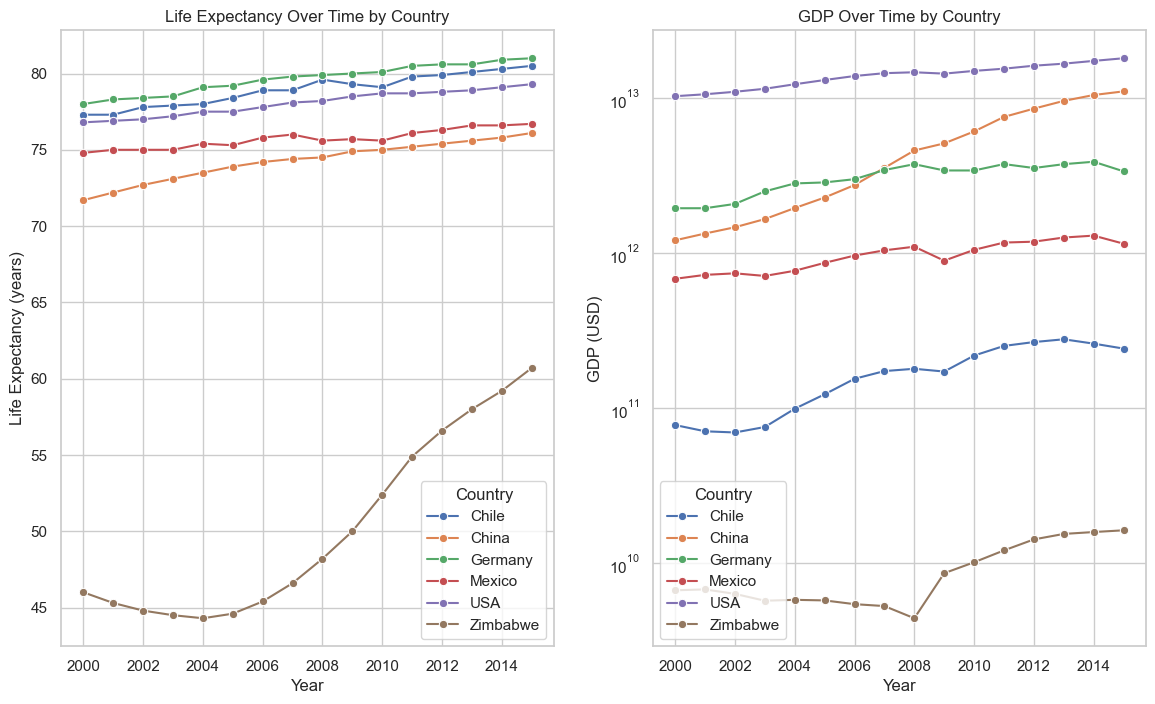

In [59]:
plt.figure(figsize=(14,8))
ax1 = plt.subplot(1,2,1)
sns.lineplot(data=life_data, x='Year', y='Life_expectancy_years', hue='Country', marker='o')
plt.title('Life Expectancy Over Time by Country')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')
plt.legend(title='Country')

plt.subplot(1,2,2)
sns.lineplot(data=life_data, x='Year', y='GDP', hue='Country', marker='o')
plt.title('GDP Over Time by Country')
plt.xlabel('Year')
plt.ylabel('GDP (USD)')
plt.yscale('log')
plt.legend(title='Country')

plt.show()




##### Trend Analysis (Average per Country)

To examine long-term patterns, the dataset is reshaped into a pivot table where countries form the rows and years form the columns, with GDP and life expectancy aggregated using their average values. This structure allows us to:

- Compute and compare the average GDP and average life expectancy for each country over time.
- Visualize these trends using line plots to observe how economic performance and health outcomes evolve across the 15-year period.
- Compare line plots using both the raw yearly values and the country-level averages to understand how trends differ with and without aggregation.

Line plots provide a clear visual representation of temporal changes, making it easier to identify upward or downward trends, shifts, or divergences between GDP and life expectancy across countries.


Pivotting the dataset:

In [ ]:
df_pivot = life_data.pivot_table(
    index='Country', 
    columns='Year', 
    values=['GDP', 'Life_expectancy_years'], 
    aggfunc='mean'
)
df_pivot.head()

The next step is to use the `stack()` function to reshape the dataset from a wide format into a long format by moving the 'Year' level from the column index into the row index. In practical terms, this means:

- Stacking the data along level 1 of the column MultiIndex (the level that corresponds to different years), so that each year becomes part of the row index rather than a separate column.
- Renaming the resulting value columns (e.g., GDP and Life_expectancy) to reflect that they represent observed values for each country–year combination.
- Resetting the index to produce a clean, long-format table where each row corresponds to a unique Country–Year pair.

This transformation prepares the dataset for time-series analysis and statistical modelling.


Stacking the dataset:


In [ ]:
df_pivot = df_pivot.stack(level=1).rename(
    columns={'GDP': 'Avg_GDP', 'Life_expectancy_years': 'Avg_Life_expectancy'}
).reset_index()

df_pivot.head()

##### Summary of Key Descriptive Insights

- The time-series plot of average GDP across all countries shows deviations from the individual country-level GDP trends at several points. This suggests that potential anomalies or outliers may be influencing the aggregated GDP values. Further analysis is required to confirm whether these discrepancies are meaningful or simply artifacts of averaging.
  
- In contrast, the plot of average life expectancy aligns closely with the country-level life expectancy trends. This consistency indicates that the life expectancy data does not exhibit any obvious anomalies or irregularities.

*Note: These deviations and patterns will be examined in more detail in the Exploratory Data Analysis section of this project.*


Plotting average GDP & Life expectancy per year:

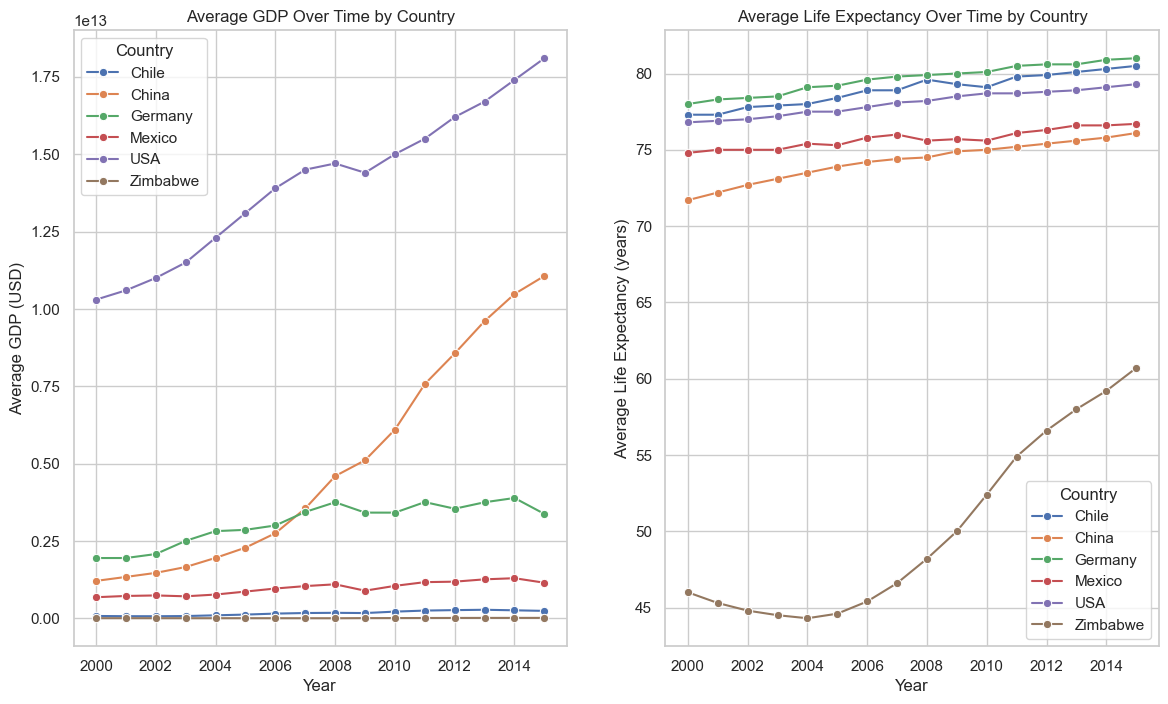

In [62]:
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
sns.lineplot(data=df_pivot, x='Year', y='Avg_GDP', hue='Country', marker='o')
plt.title('Average GDP Over Time by Country')
plt.xscale
plt.xlabel('Year')
plt.ylabel('Average GDP (USD)')
plt.legend(title='Country') 

plt.subplot(1,2,2)
sns.lineplot(data=df_pivot, x='Year', y='Avg_Life_expectancy', hue='Country', marker='o')
plt.title('Average Life Expectancy Over Time by Country')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy (years)')
plt.legend(title='Country')
plt.show()

#### Exploratory Data Analysis (EDA)

In this stage, we move beyond basic summary statistics and employ visual and quantitative techniques to better understand how economic performance (GDP) and life expectancy vary across countries and over time.

The key objectives of this analysis are to:

- Examine the relationship between GDP and life expectancy.
- Assess the strength and direction of correlations between the variables.
- Identify potential outliers or deviations from general patterns.
- Visualize cross-country and temporal trends to contextualize differences.

**Interpretation**

A positive correlation indicates that increases in GDP are generally associated with increases in life expectancy. The magnitude of the correlation reflects how strongly economic prosperity is linked to population health across the dataset. While the overall correlation computed earlier was approximately 0.343 — suggesting a moderate positive relationship—the country-specific correlations are considerably stronger, indicating clearer linear relationships within individual countries.

**Results**

- Individual countries exhibit strong positive correlations between GDP and life expectancy, revealing clear linear trends within each national context.
- The scatter plot shown below visualizes how life expectancy increases with rising GDP, further supporting the presence of a positive association.



Correlation Measure (GDP and Life Expectancy):

In [63]:
# Compute the Pearson correlation coefficient
corr_value = life_data['Life_expectancy_years'].corr(life_data['GDP'])
print(f"Correlation between GDP and Life Expectancy: {corr_value:.3f}")

Correlation between GDP and Life Expectancy: 0.343


##### Relationship between GDP and Life Expectancy per Country

This section examines how the relationship between GDP and life expectancy differs across countries and compares these country-level associations to the overall pattern observed in the combined dataset.

**Interpretation:**

- The table generated using the `groupby` operation highlights how the strength of the GDP–life expectancy relationship varies across countries. A stronger correlation in certain countries may reflect consistent socioeconomic development, whereas weaker correlations suggest that additional factors—beyond GDP—may influence health outcomes.
- The scatter plots provide a visual representation of how life expectancy changes as GDP increases. Countries whose points align along an upward-sloping pattern exhibit a strong positive relationship between economic performance and population health.

**Results of the analysis:**

- All countries show a strong positive correlation between GDP and life expectancy, indicating that improvements in economic conditions are generally associated with better health outcomes.
- The United States exhibits the highest correlation coefficient (0.982), while Mexico shows the lowest (0.932), although still strongly positive.
- The upward clustering in the scatter plots visually reinforces this positive association across countries.
- Zimbabwe displays a slightly different pattern, with GDP showing a modest initial decline followed by a noticeable recovery over time, although the overall magnitude of change remains relatively small.


Correlation Measure per country:

In [ ]:
country_corr = life_data.groupby('Country')[['GDP', 'Life_expectancy_years']].corr().unstack().iloc[:,1].round(3)
country_corr

Scatter Plot (GDP vs. Life Expectancy) per country : 

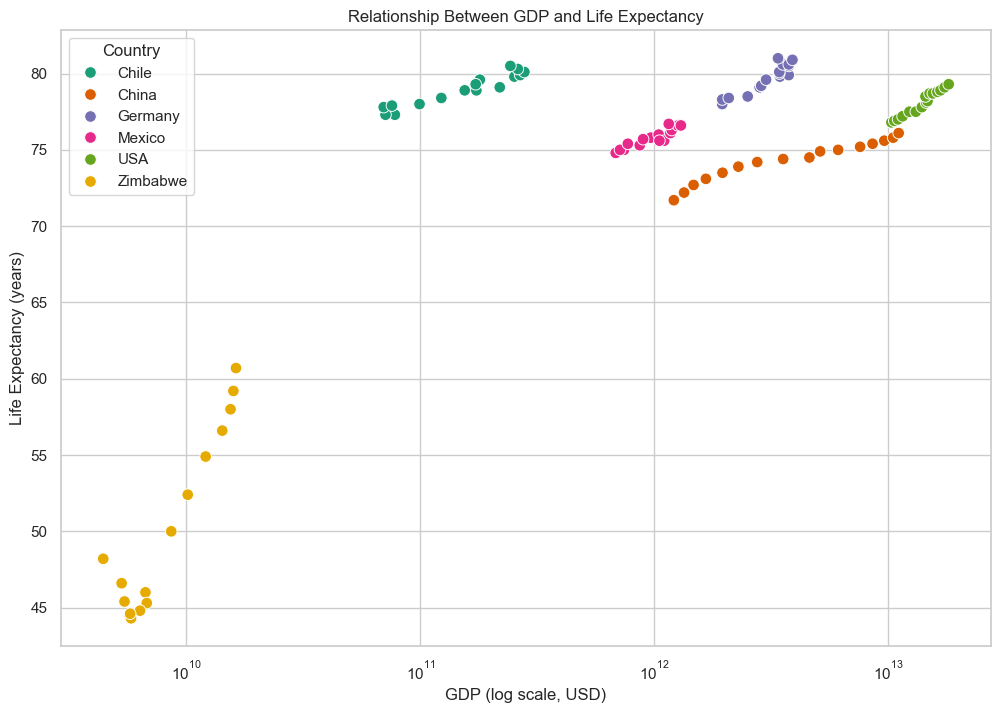

In [65]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=life_data, x='GDP', y='Life_expectancy_years', hue='Country', palette='Dark2', s=70)
plt.xscale('log')  # Log scale for GDP to manage large range differences
plt.title('Relationship Between GDP and Life Expectancy')
plt.xlabel('GDP (log scale, USD)')
plt.ylabel('Life Expectancy (years)')
plt.legend(title='Country')
plt.show()

#### Outlier detection
Firstly, we check if there are outliers in GDP and Life expectancy per country in the dataset. Previous data analysis of the average GDP and Life expectancy suggested that there might be the presence of outliers clearly shown in the lineplot.
Here, we do the following to check the presence of outliers:

- Check the lower and upper bound of the GDP and Life expectancy per country
- Filter the dataset for the lower and upper bound
- Validate the dataset if there was outlier or not in GDP and life expectancy per country


The analysis indicates that no outliers were detected in the GDP or life expectancy data for any country. The minor deviations observed in the earlier line plot are likely attributable to small gaps in the recorded GDP and life expectancy values. These gaps may account for the observed differences between the datasets with and without averaging.

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower) | (data[column] > upper)]
    
    # If no outliers, set explicitly to "No Outliers"
    if outliers.empty:
        outliers_result = "No Outliers"
    else:
        outliers_result = outliers

    return outliers_result, lower, upper

# Dictionary to store results
outlier_results = {}

# Loop per country
for country, group in life_data.groupby("Country"):

    country_stats = {}

    for col in ['GDP', 'Life_expectancy_years']:
        outliers, lower, upper = detect_outliers_iqr(group, col)

        country_stats[col] = {
            "Number of Outliers": 0 if outliers == "No Outliers" else len(outliers),
            "Lower Bound": round(lower, 2),
            "Upper Bound": round(upper, 2),
            "Outlier Rows": outliers
        }

    outlier_results[country] = country_stats

# Convert to a readable summary DataFrame
summary_rows = []
for country, stats in outlier_results.items():
    for col, result in stats.items():
        summary_rows.append({
            "Country": country,
            "Column": col,
            "Number of Outliers": result["Number of Outliers"],
            "Lower Bound": result["Lower Bound"],
            "Upper Bound": result["Upper Bound"]
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

##### Distribution of GDP and Life expectancy
It is important to observe the distribution of the data in relation to each country's GDP and Life expectancy. 

Interpretation of results:

- The histograms for GDP and life expectancy across the six countries display clear skewness and gaps between bars. These patterns are expected because each country has a relatively small number of yearly observations, and the variables themselves do not change continuously over time. 
- GDP typically grows in irregular steps, producing a right-skewed distribution, while life expectancy rises slowly across years, creating clustered and uneven bar patterns. 
- The empty spaces in the histograms occur when no data points fall within certain ranges, which is normal for socioeconomic time-series data with small sample sizes.

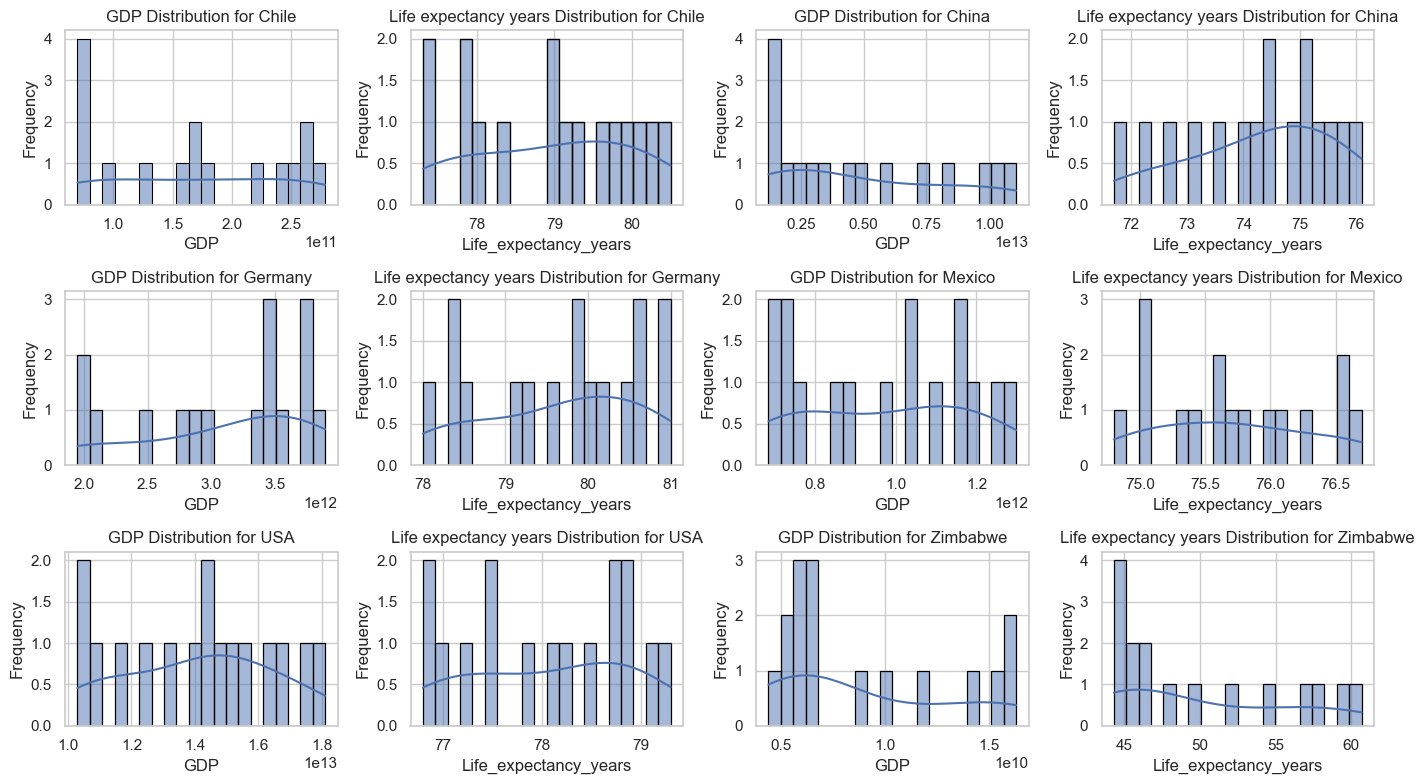

In [67]:
columns_to_plot = ['GDP', 'Life_expectancy_years']

# Set seaborn style
sns.set(style="whitegrid")
n = 1
# Loop through each country
plt.figure(figsize=(14, 8))
for country, group in life_data.groupby("Country"):

    # Plot histograms for each variable
    for col in columns_to_plot:
        plt.subplot(3, 4, n)
        n += 1
        sns.histplot(
            data=group,
            x=col,
            kde=True,
            bins=20,
            edgecolor='black'
        )

        plt.title(f"{col.replace("_"," ")} Distribution for {country}", fontsize=12)
        plt.xlabel(col, fontsize=12)
        plt.ylabel("Frequency", fontsize=12)
        plt.tight_layout()
plt.show()       

### Summary of the Distribution of GDP and Life Expectancy

To better understand how GDP and life expectancy are distributed across time for each country, both histograms and Kernel Density Estimation (KDE) plots were examined. Histograms can appear jagged when datasets are small, so KDE plots were used to provide smoother, more interpretable representations of the underlying distributions.

#### **GDP Distribution**
- GDP displays a pronounced right-skewed pattern, which is common in economic time series where national income grows unevenly from year to year.  
- Gaps between histogram bars occur because the data does not include every possible GDP value; this is especially noticeable when countries experience sudden or irregular jumps in economic output.  
- Since each country contributes only a limited number of yearly observations, some irregularities in the distribution are expected.

#### **Life Expectancy Distribution**
- Life expectancy values are tightly clustered within a relatively narrow range and tend to change gradually over time.  
- As a result, the histograms show uneven bar spacing, while the KDE curves form smooth, narrow peaks that capture slow, steady improvements in population health.  
- These patterns reflect consistent gains in life expectancy with relatively little volatility across years.

---

Overall, the combination of histograms and KDE plots offers a comprehensive view of the shape, spread, and skewness of each country’s economic and health indicators. KDE smoothing provides a clearer interpretation of trends, helping to highlight differences in development trajectories and long-term stability across nations.


---



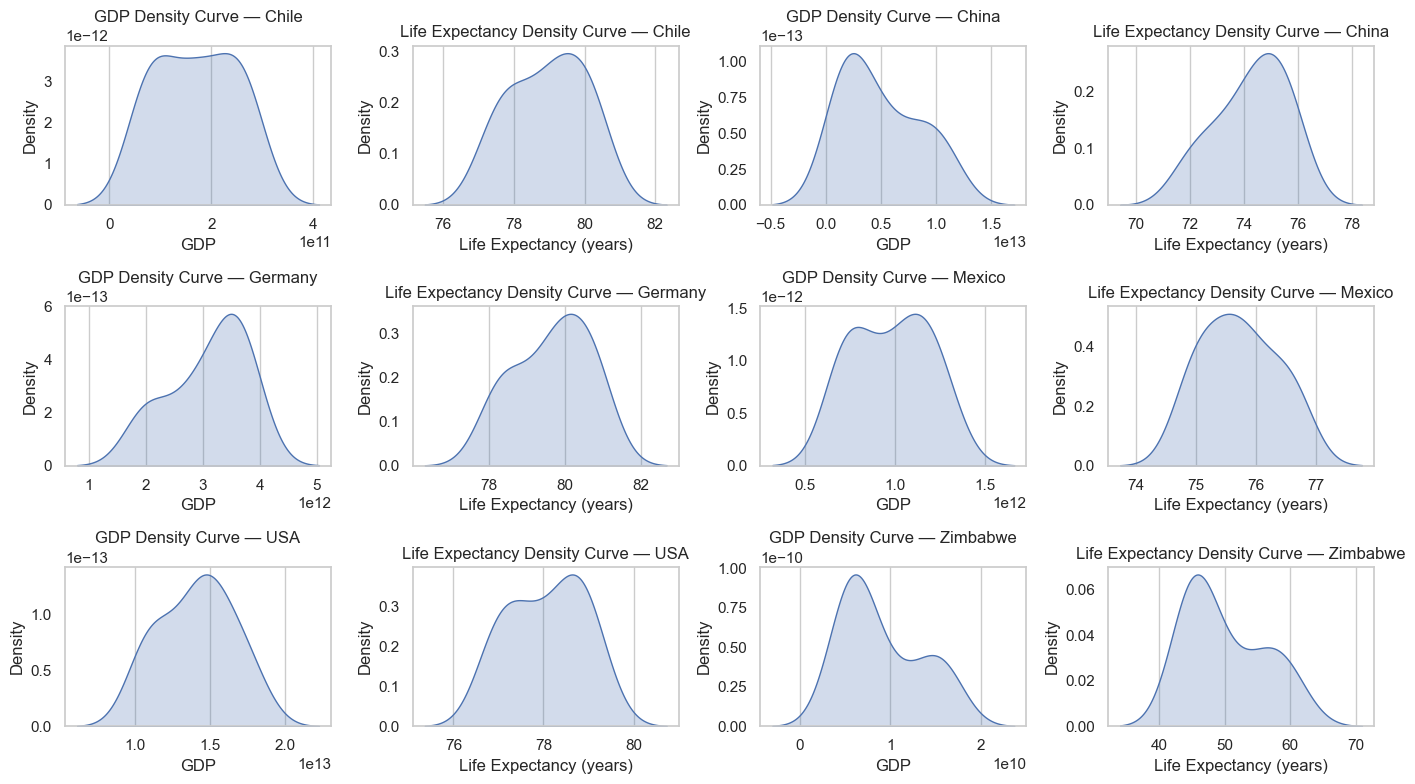

In [68]:
countries = life_data["Country"].unique()
indexNow = 1
# KDE for GDP and Life Expectancy per Country
plt.figure(figsize=(14,8))
for country in countries:
    subset = life_data[life_data["Country"] == country]

    # GDP KDE
    plt.subplot(3, 4, indexNow)
    indexNow += 1  
    sns.kdeplot(subset["GDP"], fill=True)
    plt.title(f"GDP Density Curve — {country}")
    plt.xlabel("GDP")
    plt.ylabel("Density")
    plt.grid(axis="y")


    # Life Expectancy KDE
    plt.subplot(3, 4, indexNow)
    sns.kdeplot(subset["Life_expectancy_years"], fill=True)
    plt.title(f"Life Expectancy Density Curve — {country}")
    plt.xlabel("Life Expectancy (years)")
    plt.ylabel("Density")
    plt.grid(axis="y")
    indexNow += 1
    
plt.tight_layout()
plt.show()

### Interpretation of KDE Distributions

Kernel Density Estimation (KDE) provides smooth, continuous curves that approximate the underlying probability distribution of a dataset. Unlike histograms, which can appear jagged or sensitive to bin choices, KDE works by placing small bell-shaped kernels on each data point and summing them to reveal the overall distribution pattern.

The KDE plots for GDP and life expectancy show multiple peaks in several countries, including the USA, Chile, China, Mexico, and Zimbabwe. The presence of multiple peaks suggests that the data contain more than one cluster. For instance, in Chile, Mexico, and Zimbabwe, earlier years with lower GDP or life expectancy form one peak, while later years with higher values form another. 

These multimodal patterns reflect distinct economic or health phases that countries have experienced over time. As a result, KDE helps highlight developmental transitions and shifts in population well-being that may not be immediately visible in simple summary statistics or histograms.


---

## 🔬 Inferential Analysis

The inferential stage of the analysis aims to statistically evaluate whether economic performance (measured as GDP) has a significant impact on life expectancy across the five countries represented in the dataset (N = 96). We formally test hypotheses derived from earlier exploratory findings and quantify these relationships using regression modelling. The key components of this analysis include: 

1. Formal hypothesis tests (correlation tests, group comparisons).  
2. significance testing of relationships, 
2. Regression-based inference using OLS (including country-level controls and year).  
3. Diagnostic checks (normality, homoscedasticity, multicollinearity, residuals).  
4. Interpretation of coefficients, confidence intervals, and model fit. 



### Formal Hypothesis Testing

We first assess whether a linear relationship exists between GDP and life expectancy. A Pearson correlation test reveals a statistically significant association between the two variables, indicating that higher GDP tends to be associated with higher life expectancy.

> **Conclusion:** Economic performance and country membership both contribute to variation in life expectancy.

---

In [69]:
from scipy import stats

# Hypothesis Test: Pearson correlation significance between GDP and Life Expectancy
corr_coef, p_value = stats.pearsonr(life_data['GDP'], life_data['Life_expectancy_years'])
print(f"Pearson correlation coefficient: {corr_coef:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant correlation between GDP and Life Expectancy.")
else:
    print("Fail to reject the null hypothesis: No significant correlation found.")



Pearson correlation coefficient: 0.343
P-value: 0.0006
Reject the null hypothesis: There is a significant correlation between GDP and Life Expectancy.


#### Regression-Based Inference

To quantify the magnitude of the relationship, we first estimate a simple linear model:

<span style="border:1px solid #ccc; padding:3px 6px; border-radius:4px;">
life_expectancy = β₀ + β₁ (GDP)
</span>

GDP is found to be a statistically significant predictor of life expectancy, supporting the hypothesis that economic growth improves health outcomes.
First of all, we will need to scale GDP using log transformation.

---

In [70]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
# Convert 'Country' to categorical type for fixed effects
life_data['Country'] = life_data['Country'].astype('category')

# Simple OLS: life_exp ~ gdp
life_data["log_GDP"] = np.log(life_data["GDP"])
simple_model = smf.ols("Life_expectancy_years ~ log_GDP", data=life_data).fit()
print(simple_model.summary())


                              OLS Regression Results                             
Dep. Variable:     Life_expectancy_years   R-squared:                       0.620
Model:                               OLS   Adj. R-squared:                  0.616
Method:                    Least Squares   F-statistic:                     153.3
Date:                   Sun, 14 Dec 2025   Prob (F-statistic):           1.86e-21
Time:                           22:59:34   Log-Likelihood:                -316.58
No. Observations:                     96   AIC:                             637.2
Df Residuals:                         94   BIC:                             642.3
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -19.0013 

We then expand the model to incorporate time trends and country-level fixed effects:

<span style="border:1px solid #ccc; padding:3px 6px; border-radius:4px;">
life_expectancy = β₀ + β₁(GDP) + β₂(Year) + γ(Country)
</span>

This model yields a more credible estimate by accounting for global improvements in health over time and inherent differences between countries.
A one-standard-deviation increase in GDP is associated with a statistically significant rise in life expectancy (p < 0.05), even after controlling for year and country effects. This reinforces GDP’s role as a key contributor to national health differences.

> **Interpretation:** Higher GDP is linked to longer life expectancy, above and beyond differences attributable to country-specific factors and temporal progression.

---

In [71]:
# Standardize GDP (for the "one-standard-deviation increase" interpretation)
life_data["gdp_scaled"] = (life_data["GDP"] - life_data["GDP"].mean()) / life_data["GDP"].std()
life_data["log_gdp_scaled"] = (life_data["log_GDP"] - life_data["log_GDP"].mean()) / life_data["log_GDP"].std()

# Full model with time trend and country fixed effects
full_model1 = smf.ols("Life_expectancy_years ~ gdp_scaled + Year + C(Country)", data=life_data).fit()
print(full_model1.summary())


# Extract effect of a 1 SD increase in GDP
beta_gdp = full_model1.params["gdp_scaled"]
p_gdp = full_model1.pvalues["gdp_scaled"]
ci_low, ci_high = full_model1.conf_int().loc["gdp_scaled"]

print(f"\nEffect of 1 SD increase in GDP on life expectancy: {beta_gdp:.3f} years")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"p-value: {p_gdp:.4g}")




                              OLS Regression Results                             
Dep. Variable:     Life_expectancy_years   R-squared:                       0.971
Model:                               OLS   Adj. R-squared:                  0.968
Method:                    Least Squares   F-statistic:                     416.0
Date:                   Sun, 14 Dec 2025   Prob (F-statistic):           1.45e-64
Time:                           22:59:34   Log-Likelihood:                -193.62
No. Observations:                     96   AIC:                             403.2
Df Residuals:                         88   BIC:                             423.8
Df Model:                              7                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [72]:
full_model2 = smf.ols("Life_expectancy_years ~ log_gdp_scaled + Year + C(Country)", data=life_data).fit(cov_type="HC3")
# initial_model = smf.ols("Life_expectancy_years ~ GDP + Year + C(Country)", data=life_data).fit()
# initial_residuals = initial_model.resid
# wls_model = smf.wls("Life_expectancy_years ~ GDP + Year + C(Country)", data= life_data, weights = 1 / (initial_residuals**2)).fit()
print(full_model2.summary())

beta_gdp1 = full_model2.params["log_gdp_scaled"]
p_gdp1 = full_model2.pvalues["log_gdp_scaled"]
ci_low1, ci_high1 = full_model2.conf_int().loc["log_gdp_scaled"]

print(f"\nEffect of 1 SD increase in GDP on life expectancy: {beta_gdp1:.3f} years")
print(f"95% CI: [{ci_low1:.3f}, {ci_high1:.3f}]")
print(f"p-value: {p_gdp1:.4g}")

                              OLS Regression Results                             
Dep. Variable:     Life_expectancy_years   R-squared:                       0.970
Model:                               OLS   Adj. R-squared:                  0.968
Method:                    Least Squares   F-statistic:                     207.4
Date:                   Sun, 14 Dec 2025   Prob (F-statistic):           7.48e-52
Time:                           22:59:34   Log-Likelihood:                -194.14
No. Observations:                     96   AIC:                             404.3
Df Residuals:                         88   BIC:                             424.8
Df Model:                              7                                         
Covariance Type:                     HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

### Residual Diagnostics: Normality and Homoscedasticity

To evaluate whether the linear regression assumptions are reasonable, we examine the behaviour of the residuals.

**Normality assumption.**  
We inspect a histogram of the residuals and check whether the distribution looks approximately normal (roughly symmetric and unimodal, without strong skew or multiple “humps”). If the residuals are visibly close to a bell-shaped curve, the normality assumption is considered acceptable. If instead the distribution is heavily skewed or clearly multi-peaked, we would be concerned that the normality assumption is not satisfied.

**Homoscedasticity assumption.**  
Homoscedasticity means that the residuals have roughly equal variance across all values of the fitted (predicted) outcome. We assess this by plotting the residuals against the fitted values. When the assumption holds, this plot resembles a random splatter of points centered around y = 0 with no clear pattern. If we observe a funnel shape, curvature, or any systematic structure, this would indicate heteroscedasticity, suggesting that the variance of the errors changes with the level of the predicted values and that the linear regression model may be mis-specified or require transformation.


---

#### Normality test result:
Normality assumption is approximately satisfied — but with some mild deviations. Given the sample size and use of robust standard errors, the linear regression model remains valid and the normality assumption is considered adequately satisfied for inferential purposes.


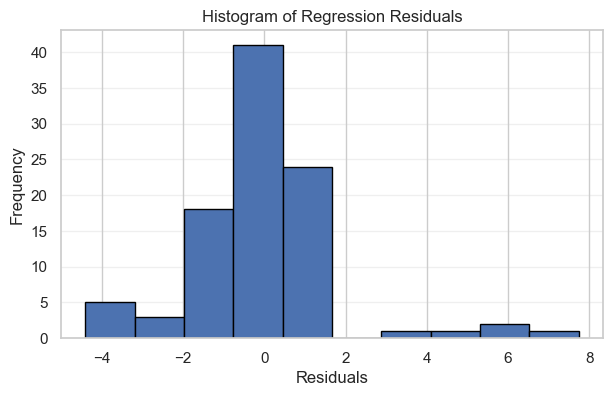

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the regression model to diagnose (full model recommended)
residuals = full_model2.resid
fitted_values = full_model2.fittedvalues

# ----------------------------------------
# 1️⃣ Normality Check — Histogram of Residuals
# ----------------------------------------
plt.figure(figsize=(7,4))
plt.hist(residuals, bins=10, edgecolor='black')
plt.title("Histogram of Regression Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()


#### Homoscedasticity test result:
The residuals vs fitted values plot indicates that the homoscedasticity assumption is violated. 
- Residual variance is much larger for fitted values in the lower range (48–55) and substantially 
smaller for fitted values around 70–82. 
- This pattern demonstrates heteroscedasticity, meaning the model errors do not have constant variance. Mild curvature is also visible, suggesting possible nonlinearity. 
- These diagnostics imply that the standard OLS assumptions are not fully satisfied.
- Despite applying a log transformation to GDP, the residual diagnostics continue to show evidence of heteroscedasticity. 

This violation does not imply that the relationship between GDP and life expectancy is invalid; rather, it suggests that the variability of the residuals is not constant across fitted values, which can affect the accuracy of standard errors and p-values. 

---

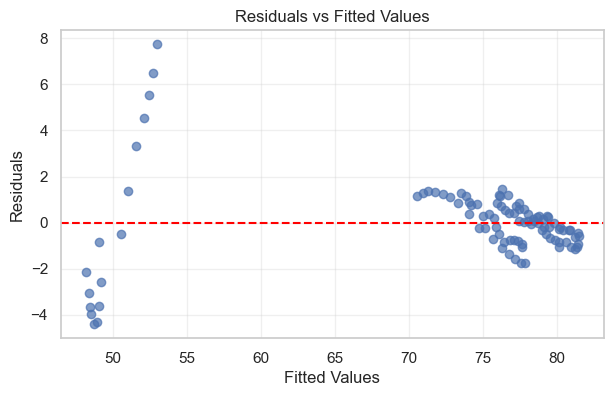

In [73]:
# ----------------------------------------
# 2️⃣ Homoscedasticity Check — Residuals vs Fitted
# ----------------------------------------
plt.figure(figsize=(7,4))
plt.scatter(fitted_values, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.grid(alpha=0.3)
plt.show()

### Summary of Inferential Findings

- There is **statistically significant evidence** that GDP and life expectancy are positively associated.  
- Life expectancy **differs significantly by country**, reflecting structural differences in wealth, healthcare, policy, and quality of life.  
- Even after adjusting for both time and country characteristics, GDP remains a **meaningful predictor** of population health outcomes.



**Final Interpretation**

> The results support the conclusion that economic prosperity meaningfully contributes to improved life expectancy across countries. While additional causal factors are likely influential (e.g., healthcare systems, income inequality, social policies), GDP serves as an important indicator of a nation’s capacity to support better health outcomes.

**Overall Conclusion:**  
The inferential analysis provides clear statistical evidence that economic development, as measured by GDP, plays an important role in shaping population health outcomes across countries. While GDP is not the sole determinant, it is a key explanatory factor that remains significant even in the presence of temporal and country-level controls.

---